# Stellarator Ensemble Analysis

This notebook treats the four stellarator long-run simulations (`long_run_a` – `long_run_d`) as **ensemble members** and demonstrates the complete `Ensemble` workflow:

| Step | What happens |
|---|---|
| **Load** | Read each CSV into a `DataStream`, collect into an `Ensemble` |
| **Inspect** | Summary, common variables, time-grid uniformity |
| **Visualise** | Overlay all four raw signals |
| **Trim** | Two paths — `ensemble.trim()` shortcut and manual per-member SSS trim |
| **Stationarity** | Per-member ADF test via `ensemble.is_stationary()` |
| **Average ensemble** | Build a single averaged trace with `compute_average_ensemble()` |
| **Statistics (T0)** | Average-first, then analyse the averaged trace |
| **Statistics (T1)** | Pooled-block: autotune per-member windows, pool block means *(preferred)* |
| **Statistics (T2)** | Member-wise `compute_statistics`, then inverse-variance aggregate |
| **Compare** | Side-by-side table and chart of all three techniques |

## 1 — Setup

In [1]:
# ── Local development path setup ──────────────────────────────────────────────
import sys
from pathlib import Path

def _find_src(start: Path) -> Path:
    for directory in [start, *start.parents]:
        if (directory / "src" / "quends").is_dir():
            return directory / "src"
    raise RuntimeError(
        f"src/quends/ not found searching up from {start}.\n"
        "Open Jupyter from within the quends_main_2 repo."
    )

_src = _find_src(Path.cwd())
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
print(f"quends source: {_src}")

quends source: /Users/eehoward/Desktop/ALL_Projects/QUENDS_CC/quends_main_2/src


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from quends import DataStream, Ensemble, from_csv
from quends import (
    MeanVariationTrimStrategy,   # SSS — not in build_trim_strategy, used manually
    TrimDataStreamOperation,
)

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR   = Path("/Users/eehoward/Desktop/quends/examples/data/gx-data-main/data/stellerator")
RUN_LABELS = ["a", "b", "c", "d"]
CSV_PATHS  = {label: DATA_DIR / f"long_run_{label}.csv" for label in RUN_LABELS}

COLUMN  = "HeatFlux_st"   # primary quantity of interest
COLOURS = {"a": "#1f77b4", "b": "#ff7f0e", "c": "#2ca02c", "d": "#d62728"}

## 2 — Load DataStreams and Build the Ensemble

In [4]:
# Load each CSV into a DataStream
streams = {label: from_csv(str(path)) for label, path in CSV_PATHS.items()}

for label, ds in streams.items():
    print(f"Run {label}: {len(ds):>6} rows  |  t = {ds.data['time'].iloc[0]:.2f} → {ds.data['time'].iloc[-1]:.2f}")

Run a:  16472 rows  |  t = 0.02 → 12000.00
Run b:  16508 rows  |  t = 0.02 → 12000.01
Run c:  16490 rows  |  t = 0.02 → 12000.00
Run d:  16501 rows  |  t = 0.02 → 12000.01


In [5]:
# Wrap them in an Ensemble — order matches RUN_LABELS
ens = Ensemble([streams[label] for label in RUN_LABELS])
print(f"Ensemble built: {len(ens)} members")

Ensemble built: 4 members


## 3 — Inspect the Ensemble

In [6]:
# High-level summary
info = ens.summary()

Ensemble members: 4
Common variables: ['HeatFluxApar_st', 'HeatFluxBpar_st', 'HeatFluxES_st', 'HeatFlux_st', 'ParticleFluxApar_st', 'ParticleFluxBpar_st', 'ParticleFluxES_st', 'ParticleFlux_st', 'Phi2_t', 'Phi2_zonal_t', 'TurbulentHeating_st', 'Wapar_st', 'Wg_st', 'Wphi_st']


In [7]:
# Columns shared by every member
print("Common variables:")
for v in ens.common_variables():
    print(f"  {v}")

Common variables:
  HeatFluxApar_st
  HeatFluxBpar_st
  HeatFluxES_st
  HeatFlux_st
  ParticleFluxApar_st
  ParticleFluxBpar_st
  ParticleFluxES_st
  ParticleFlux_st
  Phi2_t
  Phi2_zonal_t
  TurbulentHeating_st
  Wapar_st
  Wg_st
  Wphi_st


In [8]:
# Check whether all members share the same time grid
step_info = ens.check_time_steps_uniformity(verbose=True)
print(f"\nUniform time grid across members: {step_info['uniform']}")
print(f"Majority time step: {step_info['majority_step']:.6f}")

  Member 0: status=NotUniform, unique_steps=[0.28893945, 0.57078996, 0.57568354, 0.58145158, 0.5889606900000001, 0.59141751, 0.59501298, 0.60178005, 0.60228995, 0.60454839, 0.61002705, 0.61126575, 0.6121722, 0.61316119, 0.6138419900000001, 0.61698182, 0.6193902, 0.6203032900000001, 0.62292681, 0.62561936, 0.6267964, 0.62746312, 0.62755077, 0.62879557, 0.63209518, 0.6321017800000001, 0.63405143, 0.63445255, 0.63504617, 0.63513598, 0.63704114, 0.63708065, 0.63790863, 0.6379169, 0.63792967, 0.63809052, 0.63830725, 0.63998445, 0.6400062, 0.64040062, 0.64169129, 0.64316357, 0.6433892800000001, 0.64357243, 0.64427384, 0.64492449, 0.64494637, 0.64527261, 0.64540254, 0.64565854, 0.64574458, 0.64597251, 0.6461204, 0.64686971, 0.64697994, 0.6476627500000001, 0.64794183, 0.6479663, 0.64840594, 0.6489053300000001, 0.64903005, 0.64905899, 0.64906392, 0.64924553, 0.6496416700000001, 0.6501502100000001, 0.65048407, 0.65108087, 0.6511139, 0.65111892, 0.65149386, 0.65150031, 0.6518708, 0.65240414, 0.65

In [9]:
# Preview of the first member
ens.get_member(0).data.head(4)

,time,Phi2_t,Phi2_zonal_t,Wg_st,Wphi_st,Wapar_st,HeatFlux_st,HeatFluxES_st,HeatFluxApar_st,HeatFluxBpar_st,ParticleFlux_st,ParticleFluxES_st,ParticleFluxApar_st,ParticleFluxBpar_st,TurbulentHeating_st
0,0.015638,0.000060,1.771781e-15,0.001284,0.000021,0.0,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,-1.131843e-11
1,0.797554,0.000056,3.764049e-12,0.000974,0.000019,0.0,0.000044,0.000044,0.0,0.0,0.0,0.0,0.0,0.0,-8.500473e-13
2,1.579469,0.000053,1.531317e-11,0.001025,0.000018,0.0,0.000079,0.000079,0.0,0.0,0.0,0.0,0.0,0.0,8.784218e-13
3,2.361384,0.000051,3.767389e-11,0.001185,0.000018,0.0,0.000110,0.000110,0.0,0.0,0.0,0.0,0.0,0.0,1.144675e-12


## 4 — Visualise the Raw Ensemble

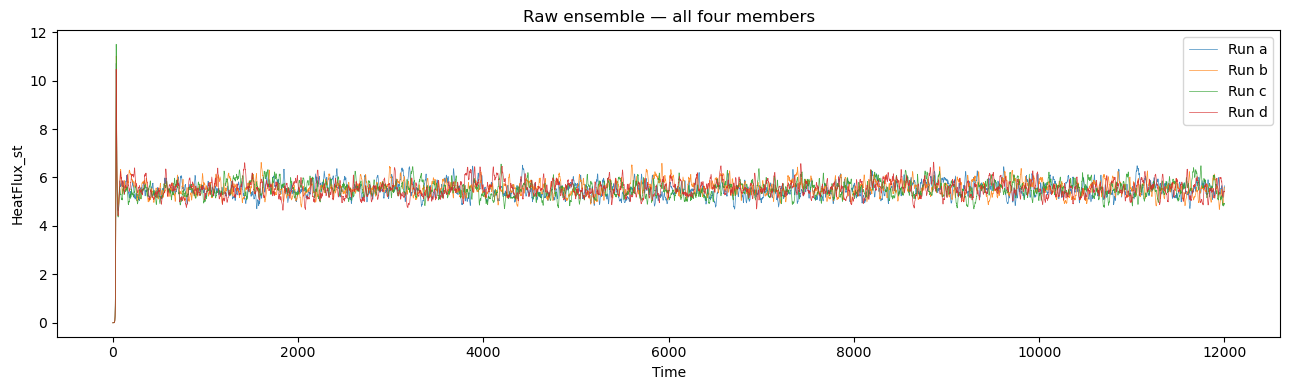

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))

for i, (label, member) in enumerate(zip(RUN_LABELS, ens.members())):
    ax.plot(member.data["time"], member.data[COLUMN],
            lw=0.5, alpha=0.85, color=COLOURS[label], label=f"Run {label}")

ax.set_xlabel("Time")
ax.set_ylabel(COLUMN)
ax.set_title("Raw ensemble — all four members")
ax.legend()
plt.tight_layout()
plt.show()

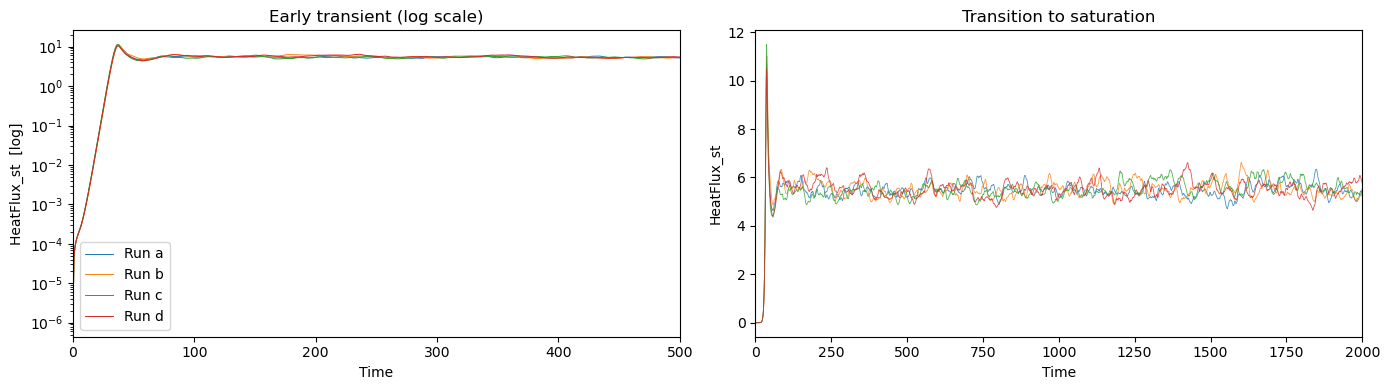

In [11]:
# Log-scale zoom on the early transient
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, member in zip(RUN_LABELS, ens.members()):
    t = member.data["time"]
    y = member.data[COLUMN]
    axes[0].semilogy(t, y.clip(lower=1e-20), lw=0.7, color=COLOURS[label], label=f"Run {label}")
    axes[1].plot(t, y, lw=0.6, alpha=0.8, color=COLOURS[label])

axes[0].set_xlim(0, 500);  axes[0].set_title("Early transient (log scale)")
axes[0].set_xlabel("Time"); axes[0].set_ylabel(f"{COLUMN}  [log]"); axes[0].legend()
axes[1].set_xlim(0, 2000); axes[1].set_title("Transition to saturation")
axes[1].set_xlabel("Time"); axes[1].set_ylabel(COLUMN)

plt.tight_layout()
plt.show()

## 5 — Trim the Ensemble

Two complementary trim paths are demonstrated.

### Path A — `Ensemble.trim()` (quick shortcut)

`ensemble.trim()` applies the same strategy to every member and returns a new `Ensemble` containing only the members that returned a non-empty result.  It delegates to `build_trim_strategy` internally, so it supports `"std"`, `"threshold"`, `"rolling_variance"`, `"self_consistent"`, and `"iqr"`.

In [12]:
# Quick trim using the robust MAD z-score strategy ("std")
ens_trimmed_std = ens.trim(
    column_name=COLUMN,
    method="std",
    window_size=200,
    start_time=100.0,
    robust=True,
)
print(f"Members after trim: {len(ens_trimmed_std)}")
print(f"{'Member':<10} {'Rows':>8} {'Start time':>12}")
print("-" * 32)
for i, member in enumerate(ens_trimmed_std.members()):
    t0 = member.data["time"].iloc[0]
    print(f"{'  '+RUN_LABELS[i]:<10} {len(member.data):>8} {t0:>12.1f}")

Members after trim: 4
Member         Rows   Start time
--------------------------------
  a           16332        100.3
  b           16367        100.4
  c           16351        100.4
  d           16363        100.0


In [14]:
# You can swap the method string for any supported strategy:
#   method="rolling_variance"  threshold=0.1
#   method="iqr"               threshold=0.05
#   method="self_consistent"   window_size=500
#   method="threshold"         threshold=0.3

ens_trimmed_rv = ens.trim(
    column_name=COLUMN,
    method="rolling_variance",
    window_size=50,
    start_time=100.0,
    threshold=0.5,
)
ens_trimmed_iqr = ens.trim(
    column_name=COLUMN,
    method="iqr",
    window_size=200,
    start_time=100.0,
    threshold=0.05,
)
ens_trimmed_sc = ens.trim(
    column_name=COLUMN,
    method="self_consistent",
    window_size=500,
    start_time=100.0,
)

print(f"Members surviving each strategy:")
print(f"  std (Quantile)       : {len(ens_trimmed_std)}")
print(f"  rolling_variance     : {len(ens_trimmed_rv)}")
print(f"  iqr                  : {len(ens_trimmed_iqr)}")
print(f"  self_consistent      : {len(ens_trimmed_sc)}")

Members surviving each strategy:
  std (Quantile)       : 4
  rolling_variance     : 4
  iqr                  : 1
  self_consistent      : 4


### Path B — Manual per-member trim with `MeanVariationTrimStrategy` (SSS)

`MeanVariationTrimStrategy` is not available through `build_trim_strategy`, so we apply it individually to each member and then reconstruct an `Ensemble` from the surviving trimmed DataStreams.

In [15]:
sss_strategy = MeanVariationTrimStrategy(
    max_lag_frac=0.5,
    verbosity=0,              # set to 1 to print detected start times
    autocorr_sig_level=0.05,
    decor_multiplier=4.0,
    std_dev_frac=0.1,
    fudge_fac=0.1,
    smoothing_window_correction=0.3,
    final_smoothing_window=10,
)
sss_op = TrimDataStreamOperation(strategy=sss_strategy)

# Apply per member, keep only non-empty results
trimmed_members = []
for label, member in zip(RUN_LABELS, ens.members()):
    tr = sss_op(member, column_name=COLUMN)
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    status = f"start = {t0:.1f}" if not tr.data.empty else "no SSS found"
    print(f"Run {label}: {status}  ({len(tr.data)} rows retained)")
    if not tr.data.empty:
        trimmed_members.append(tr)

# Rebuild as an Ensemble — this is the primary trimmed ensemble used below
ens_trimmed = Ensemble(trimmed_members)
print(f"\nTrimmed ensemble: {len(ens_trimmed)} members")

Run a: start = 592.1  (15659 rows retained)
Run b: start = 561.8  (15734 rows retained)
Run c: start = 633.1  (15621 rows retained)
Run d: start = 629.4  (15634 rows retained)

Trimmed ensemble: 4 members


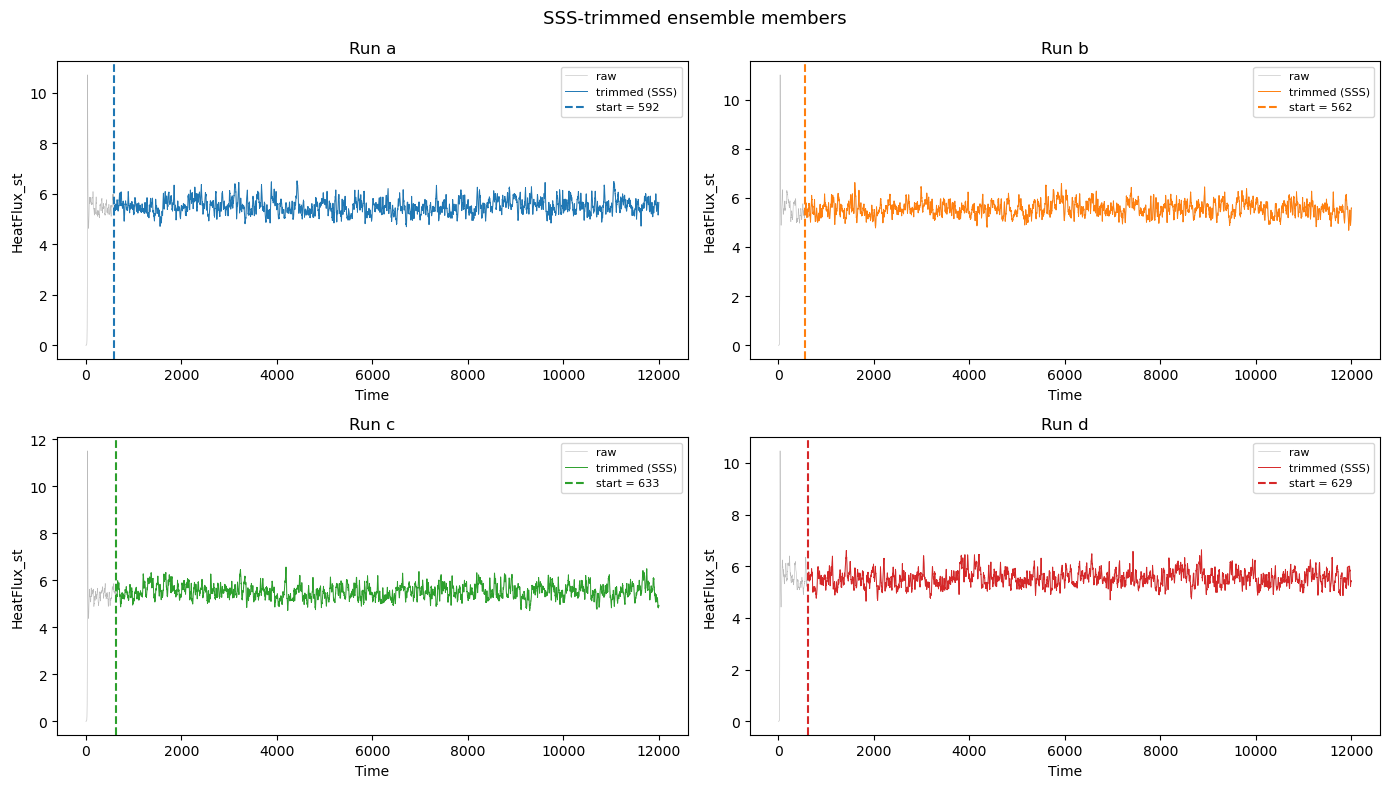

In [16]:
# Visualise: raw (grey) overlaid by trimmed (colour), with start-time marker
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for i, label in enumerate(RUN_LABELS):
    ax     = axes[i]
    raw    = ens.get_member(i)
    tr     = ens_trimmed.get_member(i) if i < len(ens_trimmed) else None
    colour = COLOURS[label]

    ax.plot(raw.data["time"], raw.data[COLUMN], lw=0.4, color="#bbbbbb", label="raw")
    if tr is not None and not tr.data.empty:
        t0 = tr.data["time"].iloc[0]
        ax.plot(tr.data["time"], tr.data[COLUMN], lw=0.7, color=colour, label="trimmed (SSS)")
        ax.axvline(t0, color=colour, lw=1.5, ls="--", label=f"start = {t0:.0f}")
    ax.set_title(f"Run {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel(COLUMN)
    ax.legend(fontsize=8)

fig.suptitle("SSS-trimmed ensemble members", fontsize=13)
plt.tight_layout()
plt.show()

## 6 — Stationarity Check

`ensemble.is_stationary()` runs an ADF test on every member and returns a per-member, per-column report.

In [17]:
stat_raw    = ens.is_stationary(COLUMN)
stat_trimmed = ens_trimmed.is_stationary(COLUMN)

print(f"{'Member':<12} {'Raw stationary':>16} {'Trimmed stationary':>20}")
print("-" * 50)
for i, label in enumerate(RUN_LABELS):
    key = f"Member {i}"
    raw_s     = stat_raw["results"].get(key, {}).get(COLUMN, "?")
    # trimmed ensemble may have fewer members
    trim_key  = f"Member {i}" if i < len(ens_trimmed) else None
    trim_s    = stat_trimmed["results"].get(trim_key, {}).get(COLUMN, "—") if trim_key else "—"
    print(f"Run {label:<8} {str(raw_s):>16} {str(trim_s):>20}")

Member         Raw stationary   Trimmed stationary
--------------------------------------------------
Run a                    True                 True
Run b                    True                 True
Run c                    True                 True
Run d                    True                 True


## 7 — Average Ensemble

`compute_average_ensemble()` detects whether all members share the same time grid.  If they do, it averages directly; otherwise it interpolates to a common grid first.

In [18]:
avg_ds = ens_trimmed.compute_average_ensemble(verbose=True)
print(f"\nAveraged trace: {len(avg_ds)} rows  |  columns: {list(avg_ds.data.columns)}")

Time grids differ; interpolating to common grid.
  Member 0: status=NotUniform, unique_steps=[0.28893945, 0.6193902, 0.62292681, 0.62561936, 0.62746312, 0.62755077, 0.62879557, 0.63209518, 0.6321017800000001, 0.63405143, 0.63445255, 0.63504617, 0.63704114, 0.63708065, 0.63790863, 0.6379169, 0.63792967, 0.63809052, 0.63830725, 0.63998445, 0.6400062, 0.64040062, 0.64169129, 0.64316357, 0.6433892800000001, 0.64357243, 0.64427384, 0.64492449, 0.64494637, 0.64527261, 0.64540254, 0.64597251, 0.6461204, 0.64686971, 0.64697994, 0.6476627500000001, 0.64840594, 0.6489053300000001, 0.64903005, 0.64905899, 0.64906392, 0.64924553, 0.6496416700000001, 0.65048407, 0.65108087, 0.6511139, 0.65111892, 0.65149386, 0.65150031, 0.6518708, 0.65240414, 0.65263857, 0.65310153, 0.65359442, 0.65388676, 0.65421473, 0.6542912200000001, 0.65462305, 0.6554185, 0.65571659, 0.65584529, 0.65598354, 0.65608274, 0.65626761, 0.65631868, 0.65632408, 0.65632785, 0.65664879, 0.65675699, 0.6572568400000001, 0.65735368, 0.657

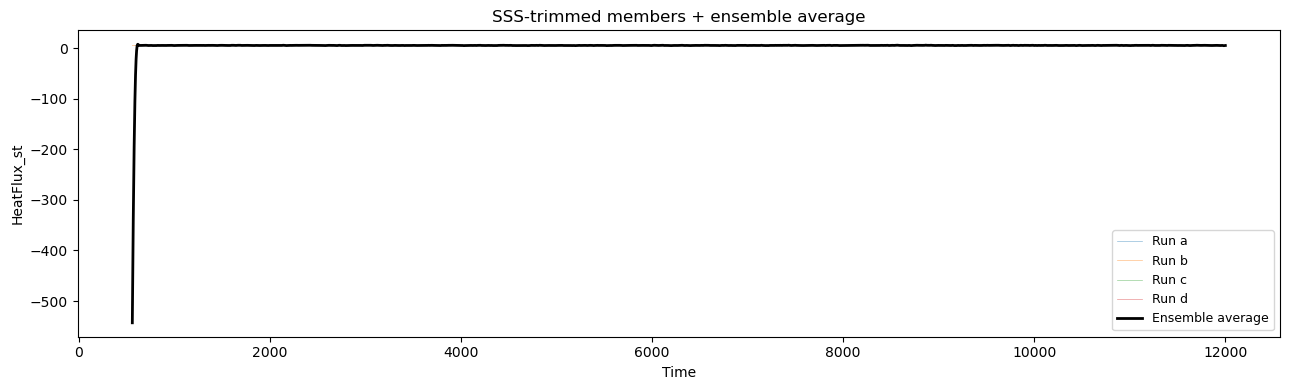

In [19]:
# Plot: individual trimmed members (light) + ensemble average (dark)
fig, ax = plt.subplots(figsize=(13, 4))

for label, member in zip(RUN_LABELS, ens_trimmed.members()):
    ax.plot(member.data["time"], member.data[COLUMN],
            lw=0.5, alpha=0.5, color=COLOURS[label], label=f"Run {label}")

ax.plot(avg_ds.data["time"], avg_ds.data[COLUMN],
        lw=2.0, color="black", label="Ensemble average", zorder=5)

ax.set_xlabel("Time")
ax.set_ylabel(COLUMN)
ax.set_title("SSS-trimmed members + ensemble average")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8 — Ensemble Statistics: Three Techniques

All three techniques are accessed through the same `compute_statistics()` call — only the `technique` argument changes.

| `technique` | Name | How it works |
|---|---|---|
| `0` | **Average-ensemble** | Build one averaged trace, run `DataStream.compute_statistics()` on it |
| `1` | **Pooled-block** | Per-member: autotune block size until Ljung-Box passes, pool all block means, compute stats on the pool *(preferred)* |
| `2` | **Member-wise IVW** | Run `compute_statistics()` on each member, aggregate with inverse-variance weighting |

### Technique 0 — Average-ensemble

In [20]:
t0_result = ens_trimmed.compute_statistics(column_name=COLUMN, technique=0)
t0_stats  = t0_result["results"][COLUMN]

print("Technique 0 — Average-ensemble")
print(f"  Mean             : {t0_stats.get('mean', float('nan')):.6f}")
print(f"  Mean uncertainty : {t0_stats.get('mean_uncertainty', float('nan')):.6f}")
ci = t0_stats.get('confidence_interval', (float('nan'), float('nan')))
print(f"  95 % CI          : ({ci[0]:.6f}, {ci[1]:.6f})")
print(f"  ESS (blocks)     : {t0_stats.get('ess_blocks', t0_stats.get('effective_sample_size', '?'))}")
print(f"  Window size      : {t0_stats.get('window_size', '?')}")

Technique 0 — Average-ensemble
  Mean             : 4.731346
  Mean uncertainty : 0.801279
  95 % CI          : (3.160839, 6.301852)
  ESS (blocks)     : 204.0
  Window size      : 85


### Technique 1 — Pooled-block *(preferred)*

In [21]:
t1_result = ens_trimmed.compute_statistics(column_name=COLUMN, technique=1)
t1_stats  = t1_result["results"][COLUMN]
t1_meta   = t1_result["metadata"]["technique_1_pooled"][COLUMN]

print("Technique 1 — Pooled-block")
print(f"  Mean             : {t1_stats.get('mean', float('nan')):.6f}")
print(f"  Mean uncertainty : {t1_stats.get('mean_uncertainty', float('nan')):.6f}")
ci1 = t1_stats.get('confidence_interval', (float('nan'), float('nan')))
print(f"  95 % CI          : ({ci1[0]:.6f}, {ci1[1]:.6f})")
print(f"  Pooled blocks    : {t1_meta.get('pooled_blocks', '?')}")
print(f"  ESS (blocks)     : {t1_stats.get('ess_blocks', '?'):.1f}")
print(f"  SE method        : {t1_stats.get('se_method', '?')}")
print(f"  LB p-value       : {t1_stats.get('ljungbox_pvalue', float('nan')):.4f}")
print(f"  All members independent: {t1_stats.get('member_all_independent', '?')}")

Technique 1 — Pooled-block
  Mean             : 5.533181
  Mean uncertainty : 0.010927
  95 % CI          : (5.511763, 5.554599)
  Pooled blocks    : 464
  ESS (blocks)     : 242.3
  SE method        : sem_ess (pooled_LB_bad)
  LB p-value       : 0.0011
  All members independent: True


In [22]:
# Per-member block metadata from Technique 1
print("Per-member block windows used:")
print(f"  Windows : {t1_meta.get('member_windows', [])}")
print(f"  Blocks  : {t1_meta.get('member_blocks', [])}")
print(f"  Status  : {t1_meta.get('member_status', [])}")
print(f"  LB pval : {[round(p, 4) for p in t1_meta.get('member_pvalues', [])]}")

Per-member block windows used:
  Windows : [127, 145, 142, 127]
  Blocks  : [123, 108, 110, 123]
  Status  : ['independent', 'independent', 'independent', 'independent']
  LB pval : [0.2669, 0.1187, 0.2257, 0.5701]


### Technique 2 — Member-wise, then inverse-variance aggregate

In [23]:
t2_result = ens_trimmed.compute_statistics(column_name=COLUMN, technique=2, diagnostics="full")
t2_stats  = t2_result["results"][COLUMN]

print("Technique 2 — Member-wise IVW aggregate")
print(f"  Mean             : {t2_stats.get('mean', float('nan')):.6f}")
print(f"  Mean uncertainty : {t2_stats.get('mean_uncertainty', float('nan')):.6f}")
ci2 = t2_stats.get('confidence_interval', (float('nan'), float('nan')))
print(f"  95 % CI          : ({ci2[0]:.6f}, {ci2[1]:.6f})")
print(f"  ESS (avg)        : {t2_stats.get('ess_blocks', float('nan')):.1f}")
print(f"  SE method        : {t2_stats.get('se_method', '?')}")

Technique 2 — Member-wise IVW aggregate
  Mean             : 5.534002
  Mean uncertainty : 0.007855
  95 % CI          : (5.518607, 5.549397)
  ESS (avg)        : 64.3
  SE method        : tech2_inverse_variance_weighted


In [ ]:
# Individual member statistics from Technique 2
indiv = t2_stats.get("individual") or {}
if indiv:
    rows_indiv = []
    for mem_key, mem_stat in indiv.items():
        ci_i = mem_stat.get("confidence_interval", (float("nan"), float("nan")))
        rows_indiv.append({
            "Member": mem_key,
            "Mean":   round(mem_stat.get("mean", float("nan")), 6),
            "SE":     round(mem_stat.get("mean_uncertainty", float("nan")), 6),
            "CI lower": round(ci_i[0], 6),
            "CI upper": round(ci_i[1], 6),
            "ESS":    round(mem_stat.get("ess_blocks", float("nan")), 1),
        })
    pd.DataFrame(rows_indiv).set_index("Member")

## 9 — Compare All Three Techniques

In [24]:
# Collect all three results into a tidy comparison DataFrame
def _extract(stats_dict, col):
    s  = stats_dict["results"][col]
    ci = s.get("confidence_interval", (float("nan"), float("nan")))
    return {
        "Mean":          round(s.get("mean", float("nan")), 6),
        "SE":            round(s.get("mean_uncertainty", float("nan")), 6),
        "CI lower":      round(ci[0], 6),
        "CI upper":      round(ci[1], 6),
        "ESS":           round(s.get("ess_blocks", s.get("effective_sample_size", float("nan"))), 1),
    }

comparison = pd.DataFrame({
    "T0 — Average-ensemble": _extract(t0_result, COLUMN),
    "T1 — Pooled-block":     _extract(t1_result, COLUMN),
    "T2 — Member-wise IVW":  _extract(t2_result, COLUMN),
}).T

comparison

,Mean,SE,CI lower,CI upper,ESS
T0 — Average-ensemble,4.731346,0.801279,3.160839,6.301852,204.0
T1 — Pooled-block,5.533181,0.010927,5.511763,5.554599,242.3
T2 — Member-wise IVW,5.534002,0.007855,5.518607,5.549397,64.3


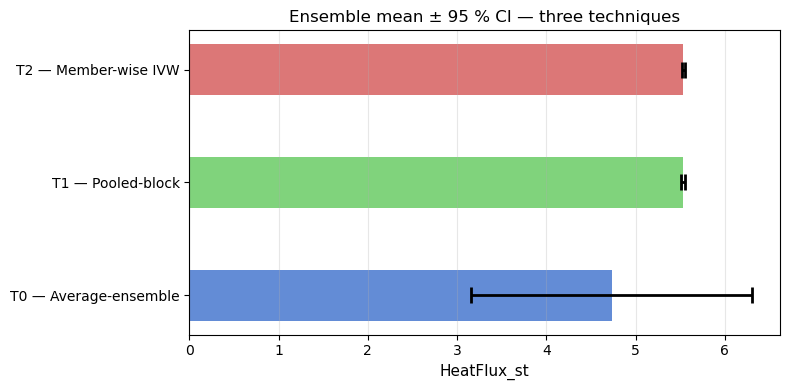

In [25]:
# Bar chart: mean ± CI for each technique
fig, ax = plt.subplots(figsize=(8, 4))

labels_tech = comparison.index.tolist()
means       = comparison["Mean"].values.astype(float)
ci_lo       = (means - comparison["CI lower"].values.astype(float))
ci_hi       = (comparison["CI upper"].values.astype(float) - means)
colours_bar = ["#4878CF", "#6ACC65", "#D65F5F"]

y_pos = range(len(labels_tech))
ax.barh(y_pos, means, xerr=[ci_lo, ci_hi],
        color=colours_bar, alpha=0.85, height=0.45, capsize=6,
        error_kw={"elinewidth": 2, "capthick": 2})

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_tech, fontsize=10)
ax.set_xlabel(COLUMN, fontsize=11)
ax.set_title("Ensemble mean ± 95 % CI — three techniques", fontsize=12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 10 — Individual Ensemble Method Calls

You can also call `mean()`, `mean_uncertainty()`, `confidence_interval()`, and `effective_sample_size()` individually — all take the same `technique` argument.

In [26]:
# All using technique=1 (pooled-block) as the default
mean_result = ens_trimmed.mean(column_name=COLUMN, technique=1)
mu_result   = ens_trimmed.mean_uncertainty(column_name=COLUMN, technique=1)
ci_result   = ens_trimmed.confidence_interval(column_name=COLUMN, technique=1)
ess_result  = ens_trimmed.effective_sample_size(column_names=COLUMN, technique=1)

print(f"Mean             : {mean_result['results'][COLUMN]:.6f}")
print(f"Mean uncertainty : {mu_result['results'][COLUMN]:.6f}")
ci_val = ci_result['results'][COLUMN]
print(f"95 % CI          : ({ci_val[0]:.6f}, {ci_val[1]:.6f})")
print(f"ESS              : {ess_result['results'][COLUMN]:.1f}")

Mean             : 5.533181
Mean uncertainty : 0.010927
95 % CI          : (5.511763, 5.554599)
ESS              : 242.3


## 11 — Repeat for All Common Variables (optional)

Pass `column_name=None` to iterate over every column shared by all members.

In [ ]:
# Compute pooled-block statistics for every common variable
all_stats = ens_trimmed.compute_statistics(column_name=None, technique=1)

summary_rows = []
for col, s in all_stats["results"].items():
    if not isinstance(s, dict) or "mean" not in s:
        continue
    ci_s = s.get("confidence_interval", (float("nan"), float("nan")))
    summary_rows.append({
        "Column":  col,
        "Mean":    round(s.get("mean", float("nan")), 8),
        "SE":      round(s.get("mean_uncertainty", float("nan")), 8),
        "CI lower":round(ci_s[0], 8),
        "CI upper":round(ci_s[1], 8),
        "ESS":     round(s.get("ess_blocks", float("nan")), 1),
    })

pd.DataFrame(summary_rows).set_index("Column")